# 06. Regenerate manuscript figures from new SIR

Notebook for regenerating Figures 3, 4 (and Table B1 numbers) from the
post-processed 15-parameter SIR result file (`sir_sweep_storm33_15p.npz`).

Coverage:
- **Figure 3(A)**  Posterior CI envelopes (Q-only / Q+Cl × Q / Cl, 4 panels)
- **Figure 3(B)**  Effective sample size N_eff vs window length
- **Figure 3(C)**  Tracer-gain heatmap (Q+Cl - Q-only IQR reduction, 15 params × 10 windows)
- **Figure 4**     Posterior evolution of the 5 identifiable parameters (histograms + trajectory)
- **Table B1**     IQR reduction at the 10-h window for all 15 parameters

Figures already obtainable elsewhere (no regeneration needed):
- Figure 1 (catchment + UH)  →  `plot_catchment_and_uh.py`
- Figure 2 (model schematic) →  manually drawn
- Figure C1 (3-layer vs simplified) → `reproduce_appendix_C.py` (uses prior_mc CSV, not SIR)
- Figure E1 (rainfall + stream Cl) → `make_F_E1_mass_balance.py` (observation only)

> Note: Appendix D (V_soil tertile) is removed in the revised manuscript.
> The `viz.plot_vsoil_tertile` call is omitted here.

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from uhf_sir import visualization as viz

# Output directory for figure PNGs
OUT = Path("../figures")
OUT.mkdir(parents=True, exist_ok=True)

# Load the post-processed 15-parameter SIR result
d = np.load("../outputs/sir_sweep_storm33_15p.npz", allow_pickle=True)
param_names = [str(s) for s in d["param_names"]]
print(f"Loaded SIR with {len(param_names)} parameters: {param_names}")

Loaded SIR with 15 parameters: ['K_s', 'psi', 'theta_d', 'K_ex', 'f_sat', 'S_max', 'tau_drain', 'uh_stretch', 'n', 'V_soil', 'alpha_soil', 'Q_threshold', 'gamma', 'lambda_sat', 'baseflow_Q']


## Figure 3(A) — Posterior CI envelopes

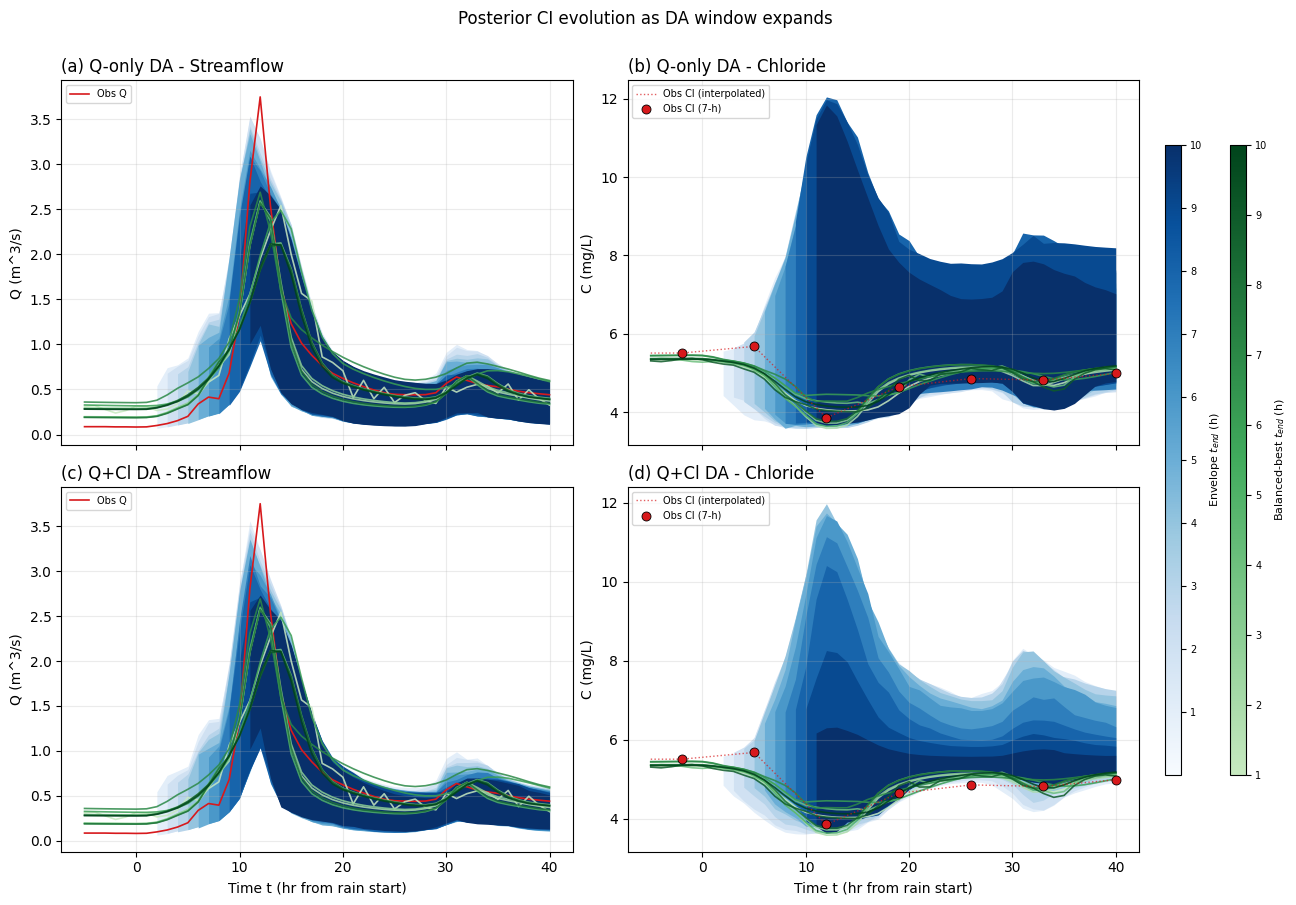

In [2]:
# Figure 3A: forecast-mode envelopes
# + observed Cl as scatter (7-h grab) and dotted line (interpolated)
# + balanced-best parameter trajectory at each window
# Two colorbars (right side):
#   - Blue:   envelope window length (built into viz.plot_sir_envelopes)
#   - Orange: balanced-best window length (this cell adds it)

import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

# Pull observed 7-h Cl
WARMUP_HR = 168
chl = pd.read_csv("../data/storm_chloride_all.csv")
c33_stream = chl[(chl["storm_id"] == 33) & (chl["kind"] == "stream")].copy()
c33_stream["t_hr"] = (c33_stream["t_sec"] - WARMUP_HR * 3600) / 3600
mask_show = (c33_stream["t_hr"] >= -5) & (c33_stream["t_hr"] <= 40)
t_obs_raw = c33_stream.loc[mask_show, "t_hr"].values
C_obs_raw = c33_stream.loc[mask_show, "Cl_mgL"].values
order    = np.argsort(t_obs_raw)
t_sorted = t_obs_raw[order]
C_sorted = C_obs_raw[order]

# Generate envelope figure (uses cm.Blues internally with norm = T_window / T_max)
fig = viz.plot_sir_envelopes(d, max_window=10.0, mode="forecast",
                              show_tmin=-5, show_tmax=40)

chloride_axes   = [ax for ax in fig.axes if "C (mg/L)" in (ax.get_ylabel() or "")]
streamflow_axes = [ax for ax in fig.axes if "Q (m"     in (ax.get_ylabel() or "")]

# Hourly-grid interpolated stream Cl (Section 2.1)
t_hr_npz = d["t_hr"]
show_npz = (t_hr_npz >= -5) & (t_hr_npz <= 40)
C_interp_hourly = np.interp(t_hr_npz[show_npz], t_sorted, C_sorted)

# Replace existing red line with two clean entries: interpolated line + scatter
for ax in chloride_axes:
    for line in list(ax.lines):
        lbl = (line.get_label() or "").lower()
        if "interp" in lbl or "obs cl" in lbl:
            line.remove()
    ax.plot(t_hr_npz[show_npz], C_interp_hourly,
            color="#d7191c", lw=1.0, ls=":", alpha=0.7, zorder=4,
            label="Obs Cl (interpolated)")
    ax.scatter(t_sorted, C_sorted, s=42, c="#d7191c", edgecolor="k",
               lw=0.6, zorder=5, label="Obs Cl (7-h)")

# Balanced-best trajectory at each window — single-hue gradient (yellow → dark orange)
windows_plot = sorted(set(int(k.split('h')[0]) for k in d.files
                          if 'h__Q_Cl_params' in k and int(k.split('h')[0]) <= 10))

Q_obs_npz = d["Q_obs"]
C_obs_npz = d["C_obs"]
sm_npz    = d["scoring_mask"]

def nse(sim, obs):
    m = np.isfinite(sim) & np.isfinite(obs)
    if m.sum() < 2:
        return np.nan
    s, o = sim[m], obs[m]
    den = np.sum((o - o.mean())**2)
    return 1.0 - np.sum((s - o)**2) / den if den > 0 else np.nan

#bb_cmap = LinearSegmentedColormap.from_list("bb_grad", ["#fee391", "#fe9929", "#cc4c02"])
bb_cmap = LinearSegmentedColormap.from_list("bb_grad", ["#c7e9c0", "#41ab5d", "#00441b"])
norm_bb = Normalize(vmin=min(windows_plot), vmax=max(windows_plot))
show = (t_hr_npz >= -5) & (t_hr_npz <= 40)

for w in windows_plot:
    Q_post = d[f"{w:02d}h__Q_Cl_Qpost"]
    C_post = d[f"{w:02d}h__Q_Cl_Cpost"]
    nq = np.array([nse(Q_post[i, sm_npz], Q_obs_npz[sm_npz]) for i in range(Q_post.shape[0])])
    nc = np.array([nse(C_post[i, sm_npz], C_obs_npz[sm_npz]) for i in range(C_post.shape[0])])
    bal = np.minimum(nq, nc)
    if np.all(np.isnan(bal)):
        continue
    bb_idx = int(np.nanargmax(bal))
    color = bb_cmap(norm_bb(w))
    for ax_q in streamflow_axes:
        ax_q.plot(t_hr_npz[show], Q_post[bb_idx, show],
                  color=color, lw=1.2, alpha=0.85, ls="-")
    for ax_c in chloride_axes:
        ax_c.plot(t_hr_npz[show], C_post[bb_idx, show],
                  color=color, lw=1.2, alpha=0.85, ls="-")

# Legends — show only labeled entries (BB lines are deliberately unlabeled)
for ax in chloride_axes + streamflow_axes:
    handles, labels = ax.get_legend_handles_labels()
    keep = [(h, l) for h, l in zip(handles, labels) if l and not l.startswith("_")]
    if keep:
        h_keep, l_keep = zip(*keep)
        ax.legend(h_keep, l_keep, loc="upper left", fontsize=7)

# Two colorbars side by side on the right
fig.subplots_adjust(right=0.88)

# Blue colorbar — envelope window length
# (viz.plot_sir_envelopes uses cm.Blues with norm = T_window / T_max where T_max = 10)
norm_blue = Normalize(vmin=0, vmax=max(windows_plot))
cbar_blue_ax = fig.add_axes([0.90, 0.15, 0.012, 0.7])
sm_blue = ScalarMappable(norm=norm_blue, cmap=cm.Blues)
sm_blue.set_array([])
cbar_blue = fig.colorbar(sm_blue, cax=cbar_blue_ax)
cbar_blue.set_label("Envelope $t_{end}$ (h)", fontsize=8)
cbar_blue.set_ticks(windows_plot)
cbar_blue.ax.tick_params(labelsize=7)

# Orange colorbar — balanced-best window length
cbar_bb_ax = fig.add_axes([0.95, 0.15, 0.012, 0.7])
sm_bb = ScalarMappable(norm=norm_bb, cmap=bb_cmap)
sm_bb.set_array([])
cbar_bb = fig.colorbar(sm_bb, cax=cbar_bb_ax)
cbar_bb.set_label("Balanced-best $t_{end}$ (h)", fontsize=8)
cbar_bb.set_ticks(windows_plot)
cbar_bb.ax.tick_params(labelsize=7)

fig.savefig(OUT / "Figure_3A_envelopes.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure 3(B) — Effective sample size N_eff

Custom figure: not in `viz` module. Plotted directly from the NPZ.

Conservative validity threshold: N_eff = 10 (Doucet & Johansen 2009).

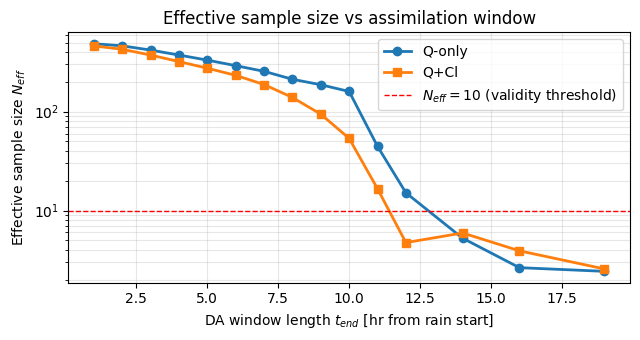


N_eff crossing of validity threshold (10):
  Q-only: first crosses at 14 h (N_eff = 5.25)
  Q+Cl: first crosses at 12 h (N_eff = 4.74)


In [3]:
# Extract per-window N_eff for both scenarios
windows = sorted(set(int(k.split('h')[0]) for k in d.files
                     if 'h__Q_only_neff' in k))
neff_q  = [float(d[f"{w:02d}h__Q_only_neff"]) for w in windows]
neff_qc = [float(d[f"{w:02d}h__Q_Cl_neff"])   for w in windows]

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(windows, neff_q,  marker="o", lw=2, label="Q-only")
ax.plot(windows, neff_qc, marker="s", lw=2, label="Q+Cl")
ax.axhline(10, color="red", ls="--", lw=1, label="$N_{eff}=10$ (validity threshold)")
ax.set_xlabel("DA window length $t_{end}$ [hr from rain start]")
ax.set_ylabel("Effective sample size $N_{eff}$")
ax.set_yscale("log")
ax.set_title("Effective sample size vs assimilation window")
ax.legend()
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
fig.savefig(OUT / "Figure_3B_neff.png", dpi=200, bbox_inches="tight")
plt.show()

# Print crossing points
print("\nN_eff crossing of validity threshold (10):")
for label, vals in [("Q-only", neff_q), ("Q+Cl", neff_qc)]:
    crossed = [w for w, v in zip(windows, vals) if v < 10]
    if crossed:
        print(f"  {label}: first crosses at {crossed[0]} h (N_eff = {vals[windows.index(crossed[0])]:.2f})")
    else:
        print(f"  {label}: stays above 10 throughout (lowest = {min(vals):.2f})")

## Figure 3(C) — Tracer-gain heatmap

IQR reduction (Q+Cl - Q-only) for each of the 15 parameters across windows.

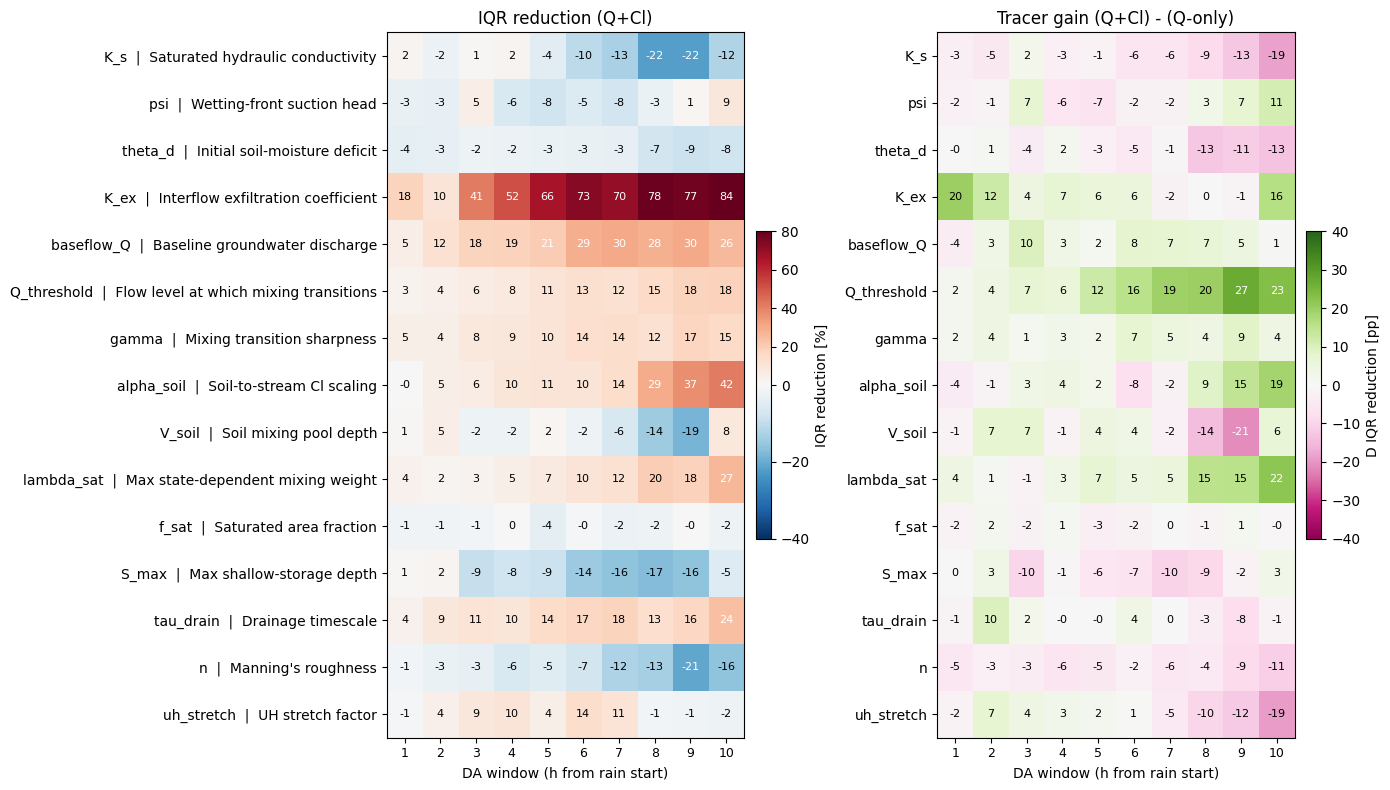

In [4]:
fig = viz.plot_iqr_heatmap(d, max_window=10.0)
fig.savefig(OUT / "Figure_3C_tracer_gain_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

## Table B1 — IQR reduction at 10-h window for all parameters

In [5]:
LOG_PARAMS = {"K_s", "K_ex", "V_soil", "tau_drain", "psi", "S_max"}

def iqr_reduction(prior_col, post_col, log=False):
    """Return 100 * (1 - IQR(post)/IQR(prior))."""
    p = prior_col[~np.isnan(prior_col)]
    q = post_col[~np.isnan(post_col)]
    if log:
        p = np.log(p[p > 0])
        q = np.log(q[q > 0])
    iqr_p = np.percentile(p, 75) - np.percentile(p, 25)
    iqr_q = np.percentile(q, 75) - np.percentile(q, 25)
    if iqr_p == 0:
        return np.nan
    return 100 * (1 - iqr_q / iqr_p)

prior   = d["prior_params"]
post_q  = d["10h__Q_only_params"]
post_qc = d["10h__Q_Cl_params"]

rows = []
for i, name in enumerate(param_names):
    is_log = name in LOG_PARAMS
    r_q  = iqr_reduction(prior[:, i], post_q[:, i], log=False)
    r_qc = iqr_reduction(prior[:, i], post_qc[:, i], log=False)
    row = {
        "param":           name,
        "IQR_red_Q_only":  r_q,
        "IQR_red_Q_Cl":    r_qc,
        "tracer_gain_pp":  r_qc - r_q,
        "prior_med":       np.nanmedian(prior[:, i]),
        "post_med_QCl":    np.nanmedian(post_qc[:, i]),
    }
    if is_log:
        row["IQR_red_Q_only_log"] = iqr_reduction(prior[:, i], post_q[:, i], log=True)
        row["IQR_red_Q_Cl_log"]   = iqr_reduction(prior[:, i], post_qc[:, i], log=True)
    rows.append(row)

table_b1 = pd.DataFrame(rows).set_index("param")

# Save and display
table_b1.to_csv(OUT / "Table_B1_IQR_reduction.csv")
with pd.option_context("display.float_format", "{:.2f}".format):
    display(table_b1.round(2))

# Quick summary: which parameters cross the 20% threshold?
print("\nParameters with IQR reduction > 20% under Q+Cl (linear):")
ident = table_b1[table_b1["IQR_red_Q_Cl"] > 20].sort_values("IQR_red_Q_Cl", ascending=False)
print(ident[["IQR_red_Q_only", "IQR_red_Q_Cl", "tracer_gain_pp"]].round(1).to_string())

# V_soil log-space note
if "IQR_red_Q_Cl_log" in table_b1.columns:
    v_log = table_b1.loc["V_soil", "IQR_red_Q_Cl_log"]
    print(f"\nV_soil log-space IQR reduction (Q+Cl): {v_log:.1f}%")

,IQR_red_Q_only,IQR_red_Q_Cl,tracer_gain_pp,prior_med,post_med_QCl,IQR_red_Q_only_log,IQR_red_Q_Cl_log
param,,,,,,,
K_s,6.62,-11.98,-18.60,0.00,0.00,18.62,-3.23
psi,-2.06,9.11,11.17,0.19,0.21,5.89,21.75
theta_d,5.22,-8.10,-13.32,0.19,0.20,NaN,NaN
K_ex,67.91,84.09,16.18,0.00,0.00,16.78,30.96
f_sat,-1.69,-2.12,-0.44,0.18,0.17,NaN,NaN
S_max,-7.96,-5.14,2.81,0.04,0.05,-3.05,-1.21
tau_drain,25.69,24.23,-1.46,22638.43,24356.37,19.38,24.26
uh_stretch,17.25,-2.12,-19.37,4.65,5.39,NaN,NaN
n,-5.27,-16.24,-10.97,0.05,0.05,NaN,NaN



Parameters with IQR reduction > 20% under Q+Cl (linear):
            IQR_red_Q_only  IQR_red_Q_Cl  tracer_gain_pp
param                                                   
K_ex                  67.9          84.1            16.2
alpha_soil            22.9          41.6            18.6
lambda_sat             4.9          26.6            21.7
baseflow_Q            25.2          26.1             0.9
tau_drain             25.7          24.2            -1.5

V_soil log-space IQR reduction (Q+Cl): 56.7%


## Figure 4 — Posterior evolution of the 5 identifiable parameters

Histograms at $t_{end} \in \{1, 3, 6, 8, 10\}$ h (prior + Q-only + Q+Cl posteriors)
plus posterior trajectory (median ± IQR) on the right column.

Identifiable parameters: K_ex, baseflow_Q, alpha_soil, V_soil, Q_threshold.

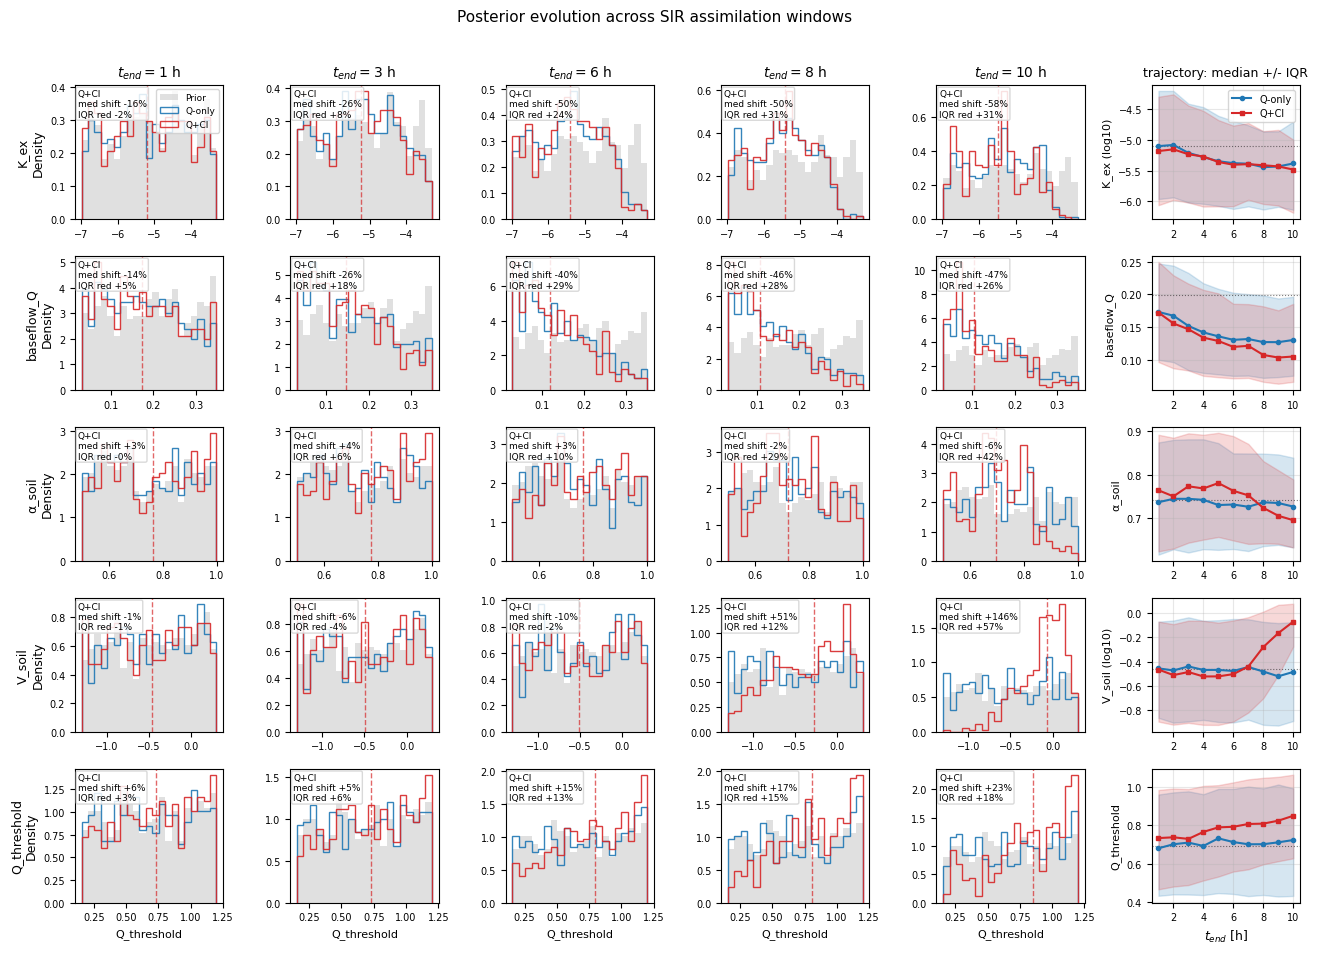

In [6]:
IDENT_PARAMS = ["K_ex", "baseflow_Q", "alpha_soil", "V_soil", "Q_threshold"]
HIST_WINDOWS = [1, 3, 6, 8, 10]
TRAJ_WINDOWS = list(range(1, 11))

PARAM_LABELS = {
    "K_ex":        "K_ex",
    "baseflow_Q":  "baseflow_Q",
    "alpha_soil":  "\u03b1_soil",
    "V_soil":      "V_soil",
    "Q_threshold": "Q_threshold"
}

def iqr_red(p, q, log=False):
    p = p[~np.isnan(p)]; q = q[~np.isnan(q)]
    if log:
        p = np.log(p[p > 0]); q = np.log(q[q > 0])
    iqr_p = np.percentile(p, 75) - np.percentile(p, 25)
    iqr_q = np.percentile(q, 75) - np.percentile(q, 25)
    return 100 * (1 - iqr_q / iqr_p) if iqr_p else np.nan

n_rows = len(IDENT_PARAMS)
n_cols_hist = len(HIST_WINDOWS)
fig, axes = plt.subplots(n_rows, n_cols_hist + 1,
                          figsize=(2.2 * (n_cols_hist + 1), 1.9 * n_rows))
fig.suptitle("Posterior evolution across SIR assimilation windows",
              fontsize=11, y=1.00)

prior = d["prior_params"]

for i, pname in enumerate(IDENT_PARAMS):
    j = param_names.index(pname)
    is_log = pname in LOG_PARAMS

    p_raw = prior[:, j]
    p_raw = p_raw[~np.isnan(p_raw)]
    p_plot = np.log10(p_raw[p_raw > 0]) if is_log else p_raw

    bins = np.linspace(p_plot.min(), p_plot.max(), 22)

    for k, w in enumerate(HIST_WINDOWS):
        ax = axes[i, k]

        post_q  = d[f"{w:02d}h__Q_only_params"][:, j]
        post_qc = d[f"{w:02d}h__Q_Cl_params"][:, j]
        post_q  = post_q[~np.isnan(post_q)]
        post_qc = post_qc[~np.isnan(post_qc)]
        if is_log:
            post_q_p  = np.log10(post_q[post_q > 0])
            post_qc_p = np.log10(post_qc[post_qc > 0])
        else:
            post_q_p, post_qc_p = post_q, post_qc

        ax.hist(p_plot,    bins=bins, alpha=0.70, color="lightgray",
                density=True, label="Prior", zorder=1)
        ax.hist(post_q_p,  bins=bins, alpha=0.9, color="tab:blue",
                density=True, histtype="step", lw=2, label="Q-only", zorder=2)
        ax.hist(post_qc_p, bins=bins, alpha=0.9, color="tab:red",
                density=True, histtype="step", lw=2, label="Q+Cl", zorder=3)

        # median shift in linear space (signed % vs prior median)
        prior_med_lin = np.median(p_raw)
        post_med_qc_lin = np.median(post_qc)
        shift_pct = 100 * (post_med_qc_lin - prior_med_lin) / abs(prior_med_lin) if prior_med_lin != 0 else 0
        red_qc = iqr_red(p_raw, post_qc, log=is_log)

        # median lines
        post_med_qc_p = np.median(post_qc_p)
        ax.axvline(post_med_qc_p, color="tab:red", lw=1.0, ls="--", alpha=0.7)

        # text annotation
        ax.text(0.02, 0.97, f"Q+Cl\nmed shift {shift_pct:+.0f}%\nIQR red {red_qc:+.0f}%",
                transform=ax.transAxes, fontsize=6.5, va="top", ha="left",
                bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="lightgray", alpha=0.85))

        if i == 0:
            ax.set_title(f"$t_{{end}} = {w}$ h", fontsize=10)
        if k == 0:
            ylabel = PARAM_LABELS[pname]
            ax.set_ylabel(f"{ylabel}\nDensity", fontsize=9)
        ax.tick_params(labelsize=7)
        if i == 0 and k == 0:
            ax.legend(fontsize=6.5, loc="upper right")

    # Trajectory column
    ax_traj = axes[i, -1]
    med_q, med_qc = [], []
    iqr_q_lo, iqr_q_hi, iqr_qc_lo, iqr_qc_hi = [], [], [], []
    for w in TRAJ_WINDOWS:
        pq  = d[f"{w:02d}h__Q_only_params"][:, j]
        pqc = d[f"{w:02d}h__Q_Cl_params"][:, j]
        pq  = pq[~np.isnan(pq)]
        pqc = pqc[~np.isnan(pqc)]
        if is_log:
            pq  = np.log10(pq[pq > 0])
            pqc = np.log10(pqc[pqc > 0])
        med_q.append(np.median(pq));   med_qc.append(np.median(pqc))
        iqr_q_lo.append(np.percentile(pq, 25));   iqr_q_hi.append(np.percentile(pq, 75))
        iqr_qc_lo.append(np.percentile(pqc, 25)); iqr_qc_hi.append(np.percentile(pqc, 75))

    prior_med = np.median(p_plot)
    ax_traj.axhline(prior_med, color="k", ls=":", lw=0.8, alpha=0.5)
    ax_traj.fill_between(TRAJ_WINDOWS, iqr_q_lo, iqr_q_hi, color="tab:blue", alpha=0.18)
    ax_traj.fill_between(TRAJ_WINDOWS, iqr_qc_lo, iqr_qc_hi, color="tab:red",  alpha=0.18)
    ax_traj.plot(TRAJ_WINDOWS, med_q,  color="tab:blue", marker="o", ms=3,
                  label="Q-only" if i == 0 else None)
    ax_traj.plot(TRAJ_WINDOWS, med_qc, color="tab:red",  marker="s", ms=3,
                  label="Q+Cl" if i == 0 else None)

    if i == 0:
        ax_traj.legend(fontsize=7, loc="best")
        ax_traj.set_title("trajectory: median +/- IQR", fontsize=9)
    if i == n_rows - 1:
        ax_traj.set_xlabel(r"$t_{end}$ [h]", fontsize=9)

    ylabel = PARAM_LABELS[pname]
    ax_traj.set_ylabel(ylabel + (" (log10)" if is_log else ""), fontsize=8)
    ax_traj.tick_params(labelsize=7)
    ax_traj.grid(True, alpha=0.3)

# Bottom row x-axis labels for histogram panels
for k in range(n_cols_hist):
    pname_last = IDENT_PARAMS[-1]
    is_log = pname_last in LOG_PARAMS
    axes[n_rows - 1, k].set_xlabel(
        PARAM_LABELS[pname_last] + (" (log10)" if is_log else ""),
        fontsize=8)

fig.tight_layout(rect=(0, 0, 1, 0.99))
fig.savefig(OUT / "Figure_4_posterior_evolution.png", dpi=200, bbox_inches="tight")
plt.show()


## Appendix D — V_soil tertile decomposition

Decomposes the 10-h Q+Cl posterior into V_soil tertiles. Used to
support the 'three non-exclusive interpretations' framing in §4.2/§4.4
of the manuscript. The Spearman correlation table is omitted because
the V_soil-Q_threshold sign was not robust across SIR replicates.

Tertile boundaries: 0.655 m / 1.081 m


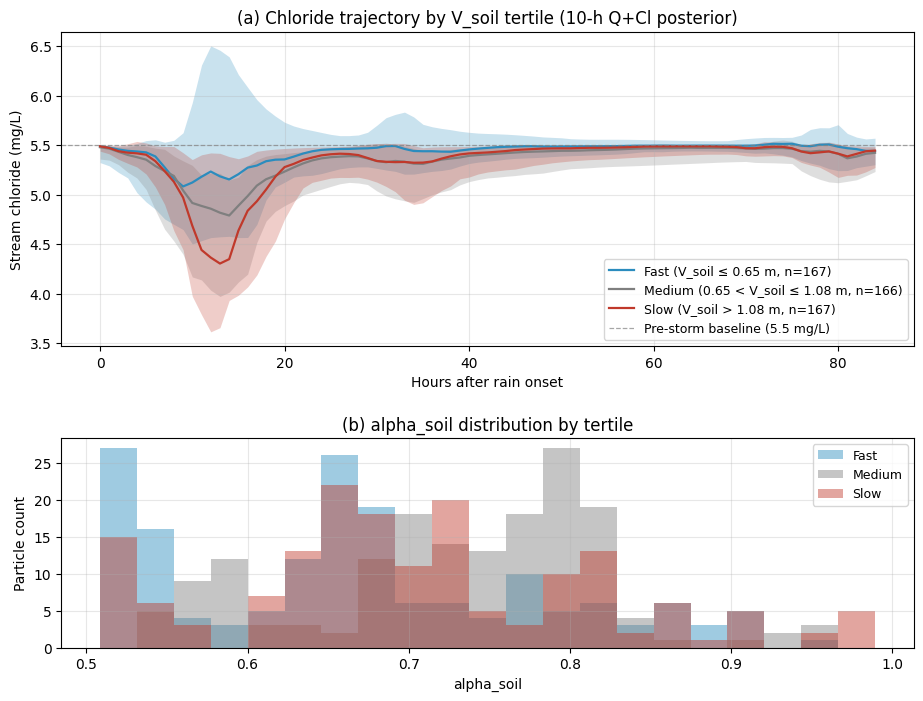


tertile       n          V range (m)   med trough    a_med
------------------------------------------------------------
Fast        167              ≤ 0.655         5.08    0.663
Medium      166       (0.655, 1.081]         4.79    0.747
Slow        167              > 1.081         4.30    0.691

Observed trough: 3.86 mg/L


In [7]:
# Figure D1: V_soil tertile decomposition (2-panel minimal version)
# - (a) Stream Cl trajectory by tertile
# - (b) alpha_soil posterior distribution by tertile
# Q_threshold panel is intentionally omitted (Section 4.2 focuses on
# V_soil-alpha_soil trade-off only).

post_params = d["10h__Q_Cl_params"]
post_C      = d["10h__Q_Cl_Cpost"]
t_hr        = d["t_hr"]

i_V = param_names.index("V_soil")
i_a = param_names.index("alpha_soil")

V = post_params[:, i_V]
a = post_params[:, i_a]

# Drop NaN rows
mask_valid = ~np.isnan(V)
V_v        = V[mask_valid]
a_v        = a[mask_valid]
post_C_v   = post_C[mask_valid]

# Tertile boundaries (33rd / 67th percentile)
t1 = np.percentile(V_v, 100/3)
t2 = np.percentile(V_v, 200/3)

fast = V_v <= t1
med  = (V_v > t1) & (V_v <= t2)
slow = V_v >  t2

print(f"Tertile boundaries: {t1:.3f} m / {t2:.3f} m")

# Plot
fig = plt.figure(figsize=(11, 8))
gs  = fig.add_gridspec(2, 1, height_ratios=[1.5, 1], hspace=0.35)
ax_top = fig.add_subplot(gs[0, 0])
ax_a   = fig.add_subplot(gs[1, 0])

show   = (t_hr >= 0) & (t_hr <= 84)
t_show = t_hr[show]
colors = {"Fast": "#2b8cbe", "Medium": "#7f7f7f", "Slow": "#c0392b"}

# Panel (a): chloride trajectory by tertile
for label, m, lab in [
    ("Fast",   fast, f"V_soil ≤ {t1:.2f} m"),
    ("Medium", med,  f"{t1:.2f} < V_soil ≤ {t2:.2f} m"),
    ("Slow",   slow, f"V_soil > {t2:.2f} m"),
]:
    sub = post_C_v[m][:, show]
    if sub.size == 0:
        continue
    medline = np.nanmedian(sub, axis=0)
    lo      = np.nanpercentile(sub,  5, axis=0)
    hi      = np.nanpercentile(sub, 95, axis=0)
    n       = int(m.sum())
    ax_top.fill_between(t_show, lo, hi, color=colors[label], alpha=0.25, lw=0)
    ax_top.plot(t_show, medline, color=colors[label], lw=1.6,
                label=f"{label} ({lab}, n={n})")

ax_top.axhline(5.5, color="gray", ls="--", lw=0.9, alpha=0.7,
               label="Pre-storm baseline (5.5 mg/L)")
ax_top.set_xlabel("Hours after rain onset")
ax_top.set_ylabel("Stream chloride (mg/L)")
ax_top.set_title("(a) Chloride trajectory by V_soil tertile (10-h Q+Cl posterior)")
ax_top.legend(loc="lower right", fontsize=9)
ax_top.grid(alpha=0.3)

# Panel (b): alpha_soil distribution by tertile
bins = np.linspace(a_v.min(), a_v.max(), 22)
ax_a.hist(a_v[fast], bins=bins, alpha=0.45, color=colors["Fast"],   label="Fast")
ax_a.hist(a_v[med],  bins=bins, alpha=0.45, color=colors["Medium"], label="Medium")
ax_a.hist(a_v[slow], bins=bins, alpha=0.45, color=colors["Slow"],   label="Slow")
ax_a.set_xlabel("alpha_soil")
ax_a.set_ylabel("Particle count")
ax_a.set_title("(b) alpha_soil distribution by tertile")
ax_a.legend(fontsize=9)
ax_a.grid(alpha=0.3)

fig.savefig(OUT / "Figure_D1_vsoil_tertile.png", dpi=200, bbox_inches="tight")
plt.show()

# Tertile statistics for Table D1
mask_cal = (t_hr >= 0) & (t_hr <= 84)
C_cal    = post_C_v[:, mask_cal]

print()
print(f"{'tertile':10s} {'n':>4s} {'V range (m)':>20s} {'med trough':>12s} {'a_med':>8s}")
print("-" * 60)
for nm, idx, lab in [("Fast",   fast, f"≤ {t1:.3f}"),
                     ("Medium", med,  f"({t1:.3f}, {t2:.3f}]"),
                     ("Slow",   slow, f"> {t2:.3f}")]:
    Cm     = np.nanmedian(C_cal[idx], axis=0)
    trough = np.nanmin(Cm)
    print(f"{nm:10s} {idx.sum():>4d} {lab:>20s} {trough:>12.2f} {np.median(a_v[idx]):>8.3f}")
print()
print("Observed trough: 3.86 mg/L")

## Appendix E — Rainfall and stream chloride forcing (Figure E1)

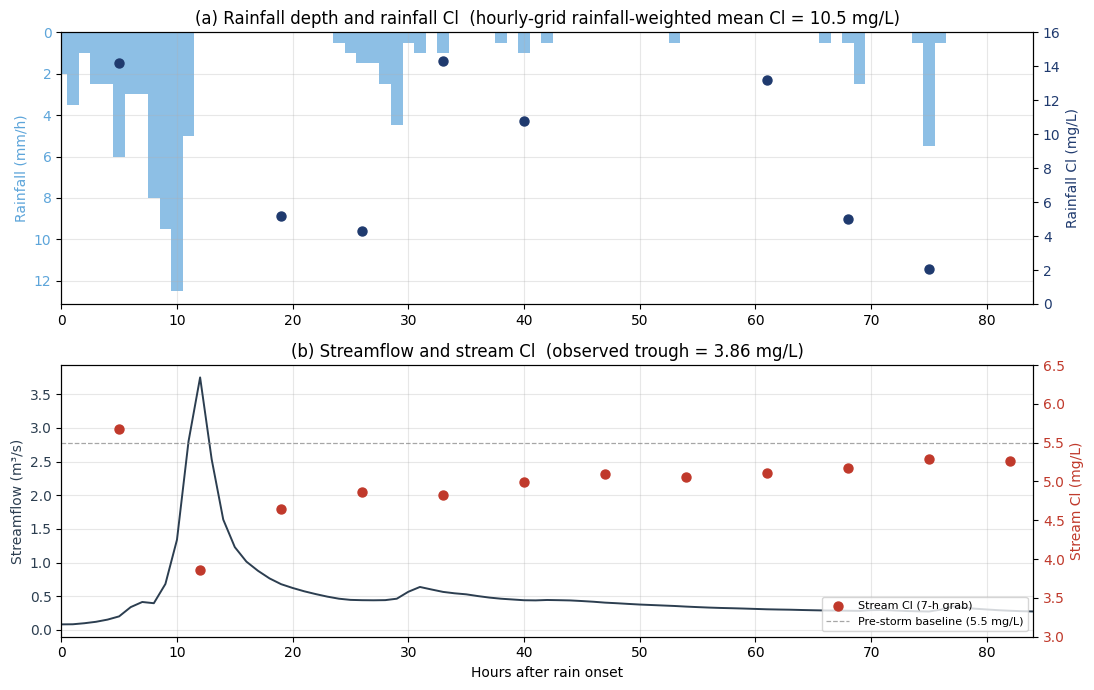

Chloride mass balance for storm 33 over the 84-hour calibration window:
  Rainfall depth (0-84 h):          85.0 mm
  Catchment rainfall Cl input:      1089 kg
  Stream Cl output:                 753 kg
  Net catchment retention:          336 kg (31% of input)


In [8]:
# Figure E1: rainfall and stream chloride forcing for storm 33
# + chloride mass balance over the 84-h calibration window

ts = pd.read_csv("../data/storm_timeseries_all.csv")
cl = pd.read_csv("../data/storm_chloride_all.csv")

# Storm 33 — rain start = first in_scoring row of the timeseries
ts33_full = ts[ts["storm_id"] == 33].reset_index(drop=True)
t0 = ts33_full.loc[ts33_full["in_scoring"], "t_sec"].iloc[0]   # rain onset

# Hourly time series within 0–84 h calibration window
ts33 = ts33_full[ts33_full["in_scoring"]].reset_index(drop=True)
t_h    = (ts33["t_sec"].values - t0) / 3600.0
rain_h = ts33["rain_mmhr"].values
Q_h    = ts33["Q_obs_m3s"].values

# Chloride samples within the window (in_scoring is per-stream only,
# so we filter by t_h directly)
cl33 = cl[cl["storm_id"] == 33].copy()
cl33["t_h"] = (cl33["t_sec"].values - t0) / 3600.0
cl_rain = cl33[(cl33["kind"] == "rain")
               & (cl33["t_h"] >= 0) & (cl33["t_h"] <= 84)].sort_values("t_h")
cl_str  = cl33[(cl33["kind"] == "stream")
               & (cl33["t_h"] >= 0) & (cl33["t_h"] <= 84)].sort_values("t_h")

# Rainfall-weighted mean Cl on hourly grid (Section 2.1 of manuscript)
cl_rain_interp = np.interp(t_h, cl_rain["t_h"].values, cl_rain["Cl_mgL"].values)
wmean  = (rain_h * cl_rain_interp).sum() / rain_h.sum()
trough = float(cl_str["Cl_mgL"].min())

# Stream Cl on hourly grid (linearly interpolated, padded at ends)
cl_str_t = cl_str["t_h"].values
cl_str_C = cl_str["Cl_mgL"].values
t_ext = np.concatenate([[0.0], cl_str_t, [t_h.max()]])
C_ext = np.concatenate([[5.5], cl_str_C, [cl_str_C[-1]]])
cl_stream_interp = np.interp(t_h, t_ext, C_ext)

# Mass balance accounting (Appendix E Table E1)
area_m2 = 1.219e6                                              # catchment area
mass_in_kg  = (rain_h * cl_rain_interp).sum() * 1e-3 * area_m2 / 1000   # mm/h × mg/L → kg
mass_out_kg = (Q_h * 3600 * cl_stream_interp).sum() / 1000              # m³/s × s × mg/L → kg
net_kg      = mass_in_kg - mass_out_kg

# ---- Figure E1 ------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7))

# Top panel: rainfall + rainfall Cl
ax1.bar(t_h, rain_h, width=1.0, color="#5da5da", alpha=0.7, edgecolor="none")
ax1.invert_yaxis()
ax1.set_ylabel("Rainfall (mm/h)", color="#5da5da")
ax1.tick_params(axis="y", labelcolor="#5da5da")
ax1.set_xlim(0, t_h.max())
ax1.grid(alpha=0.3)

ax1b = ax1.twinx()
ax1b.scatter(cl_rain["t_h"].values, cl_rain["Cl_mgL"].values,
             s=42, c="#1f3a6e", zorder=5, label="Rainfall Cl (7-h grab)")
ax1b.set_ylabel("Rainfall Cl (mg/L)", color="#1f3a6e")
ax1b.tick_params(axis="y", labelcolor="#1f3a6e")
ax1b.set_ylim(0, 16)

ax1.set_title(f"(a) Rainfall depth and rainfall Cl  "
              f"(hourly-grid rainfall-weighted mean Cl = {wmean:.1f} mg/L)")

# Bottom panel: streamflow + stream Cl
ax2.plot(t_h, Q_h, color="#2c3e50", lw=1.4, label="Streamflow")
ax2.set_xlabel("Hours after rain onset")
ax2.set_ylabel("Streamflow (m³/s)", color="#2c3e50")
ax2.tick_params(axis="y", labelcolor="#2c3e50")
ax2.set_xlim(0, t_h.max())
ax2.grid(alpha=0.3)

ax2b = ax2.twinx()
ax2b.scatter(cl_str["t_h"].values, cl_str["Cl_mgL"].values,
             s=42, c="#c0392b", zorder=5, label="Stream Cl (7-h grab)")
ax2b.axhline(5.5, color="gray", ls="--", lw=0.9, alpha=0.7,
             label="Pre-storm baseline (5.5 mg/L)")
ax2b.set_ylabel("Stream Cl (mg/L)", color="#c0392b")
ax2b.tick_params(axis="y", labelcolor="#c0392b")
ax2b.set_ylim(3, 6.5)
ax2b.legend(loc="lower right", fontsize=8)

ax2.set_title(f"(b) Streamflow and stream Cl  (observed trough = {trough:.2f} mg/L)")

fig.tight_layout()
fig.savefig(OUT / "Figure_E1_mass_balance.png", dpi=200, bbox_inches="tight")
plt.show()

# ---- Mass balance table (Table E1) ----------------------------------
print("Chloride mass balance for storm 33 over the 84-hour calibration window:")
print(f"  Rainfall depth (0-84 h):          {rain_h.sum():.1f} mm")
print(f"  Catchment rainfall Cl input:      {mass_in_kg:.0f} kg")
print(f"  Stream Cl output:                 {mass_out_kg:.0f} kg")
print(f"  Net catchment retention:          {net_kg:.0f} kg "
      f"({100*net_kg/mass_in_kg:.0f}% of input)")

## Summary of generated files


In [9]:
for f in sorted(OUT.glob("*")):
    sz_kb = f.stat().st_size / 1024
    print(f"  {f.name}   ({sz_kb:.1f} KB)")

  Figure_3A_envelopes.png   (638.9 KB)
  Figure_3B_neff.png   (80.7 KB)
  Figure_3C_tracer_gain_heatmap.png   (309.3 KB)
  Figure_4_posterior_evolution.png   (406.8 KB)
  Figure_D1_vsoil_tertile.png   (171.6 KB)
  Figure_E1_mass_balance.png   (159.1 KB)
  Table_B1_IQR_reduction.csv   (1.9 KB)
